# Joint Sharp Wave Ripple Detection

This tutorial walks through a compact joint SWR workflow in `neuro_py`. We start with a short simulated LFP segment where the expected SWR times are known, then run the same detector on the real session `S:\data\HMC\HMC1\day8`.

We will:

1. simulate ripple-channel and sharp-wave-channel LFP with visible SWRs,
2. detect the simulated SWRs and compare them with the known event times,
3. run the detector on a real session and inspect the CellExplorer-style event table,
4. load only the short real-data LFP segment needed for plotting, and
5. visualize raw channels and feature traces in stacked panels so the joint decision is easy to read.


In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage, signal

import neuro_py as npy
from neuro_py.detectors.sharp_wave_ripple import detect_sharp_wave_ripples

npy.plotting.set_plotting_defaults()


## 1) Simulated sharp wave ripples

Before looking at a real recording, it helps to use data where we know the answer. Here we simulate a short 1.5 second two-channel LFP segment with brown noise, visible 165 Hz ripple bursts, and paired slow sharp-wave deflections.

In real hippocampal data, the sharp-wave feature is useful because it helps reject noise or non-SWR high-frequency events that can otherwise have ripple-band power.

This section is also designed to be easy to tune locally. Edit the simulation amplitudes or detector thresholds below and rerun the cells to see how the joint detector responds. A future Marimo version could expose these same values as reactive sliders, but this static tutorial keeps the current Zensical build path simple.


In [2]:
RIPPLE_FREQUENCY = 165.0


def normalize(signal_in):
    signal_in = np.asarray(signal_in, dtype=float)
    return (signal_in - signal_in.mean()) / signal_in.std()


def brown_noise(n_samples, seed=None):
    """Generate normalized brown noise with power decreasing at low frequencies."""
    rng = np.random.default_rng(seed)
    uneven = n_samples % 2
    spectrum = rng.normal(size=n_samples // 2 + 1 + uneven) + 1j * rng.normal(
        size=n_samples // 2 + 1 + uneven
    )
    scale = np.arange(1, spectrum.size + 1)
    noise = np.fft.irfft(spectrum / scale).real
    if uneven:
        noise = noise[:-1]
    return normalize(noise)


def simulate_swr_session(
    fs=1250.0,
    duration=1.5,
    swr_times=(0.45, 1.02),
    ripple_amplitude=2.0,
    ripple_duration=0.100,
    sharp_wave_amplitude=-2.8,
    sharp_wave_duration=0.140,
    ripple_noise_amplitude=1.1,
    sharp_wave_noise_amplitude=0.8,
    seed=7,
):
    timestamps = np.arange(0.0, duration, 1.0 / fs)
    ripple_channel = ripple_noise_amplitude * brown_noise(timestamps.size, seed=seed)
    sharp_wave_channel = sharp_wave_noise_amplitude * brown_noise(
        timestamps.size, seed=seed + 1
    )

    ripple_carrier = np.sin(2 * np.pi * RIPPLE_FREQUENCY * timestamps)
    for center in swr_times:
        ripple_envelope = np.exp(
            -((timestamps - center) ** 2) / (2 * (ripple_duration / 6.0) ** 2)
        )
        sharp_wave_envelope = np.exp(
            -((timestamps - center) ** 2) / (2 * (sharp_wave_duration / 6.0) ** 2)
        )
        ripple_channel += ripple_amplitude * ripple_carrier * ripple_envelope
        sharp_wave_channel += sharp_wave_amplitude * sharp_wave_envelope

    truth = pd.DataFrame(
        {
            "event_type": "swr",
            "true_time": np.asarray(swr_times, dtype=float),
            "true_start": np.asarray(swr_times, dtype=float) - ripple_duration / 2.0,
            "true_stop": np.asarray(swr_times, dtype=float) + ripple_duration / 2.0,
        }
    )
    return timestamps, ripple_channel, sharp_wave_channel, truth


sim_timestamps, sim_ripple, sim_sharp_wave, sim_truth = simulate_swr_session()

sim_events = detect_sharp_wave_ripples(
    ripple_signal=sim_ripple,
    sharp_wave_signal=sim_sharp_wave,
    fs=1250.0,
    timestamps=sim_timestamps,
    ripple_channel=0,
    low_threshold=0.6,
    high_threshold=1.8,
    sharp_wave_low_threshold=0.4,
    sharp_wave_high_threshold=1.4,
    smooth_sigma=0.002,
    min_duration=0.020,
    max_duration=0.120,
    sharp_wave_min_duration=0.020,
    sharp_wave_max_duration=0.220,
    peak_window=0.060,
    merge_gap=0.010,
    boundary_mode="union",
    save_mat=False,
)

sim_events[["start", "stop", "peaks", "peakNormedPower", "sharp_wave_peakNormedPower"]]


,start,stop,peaks,peakNormedPower,sharp_wave_peakNormedPower
0,0.4168,0.4792,0.4528,5.148345,2.035222
1,0.9880,1.0472,1.0288,5.136576,2.681947


### Compare detections with known event times

Because the simulated SWR times are known, we can make a quick sanity table. Each simulated SWR should have a detected ripple trough nearby.


In [3]:
def nearest_detection_time(event_time, detected_peaks):
    if len(detected_peaks) == 0:
        return np.nan, np.nan
    distances = np.abs(detected_peaks - event_time)
    nearest = int(np.argmin(distances))
    return float(detected_peaks[nearest]), float(distances[nearest])


detected_peaks = sim_events["peaks"].to_numpy(dtype=float)
rows = []
for event in sim_truth.itertuples(index=False):
    nearest_peak, error = nearest_detection_time(event.true_time, detected_peaks)
    rows.append(
        {
            "event_type": event.event_type,
            "true_time": event.true_time,
            "nearest_detected_peak": nearest_peak,
            "error_ms": error * 1000.0,
            "detected": bool(error <= 0.025) if not np.isnan(error) else False,
        }
    )

sim_comparison = pd.DataFrame(rows)
display(sim_comparison)


,event_type,true_time,nearest_detected_peak,error_ms,detected
0,swr,0.45,0.4528,2.8,True
1,swr,1.02,1.0288,8.8,True


### Plot the simulated detector result

The short simulation window lets the ripple oscillations remain visible in the raw LFP trace. Gray spans mark the known simulated SWR windows, and orange spans mark the detector output. The paired sharp-wave channel is plotted underneath the ripple channel so the joint event structure is visible without crowding the figure.


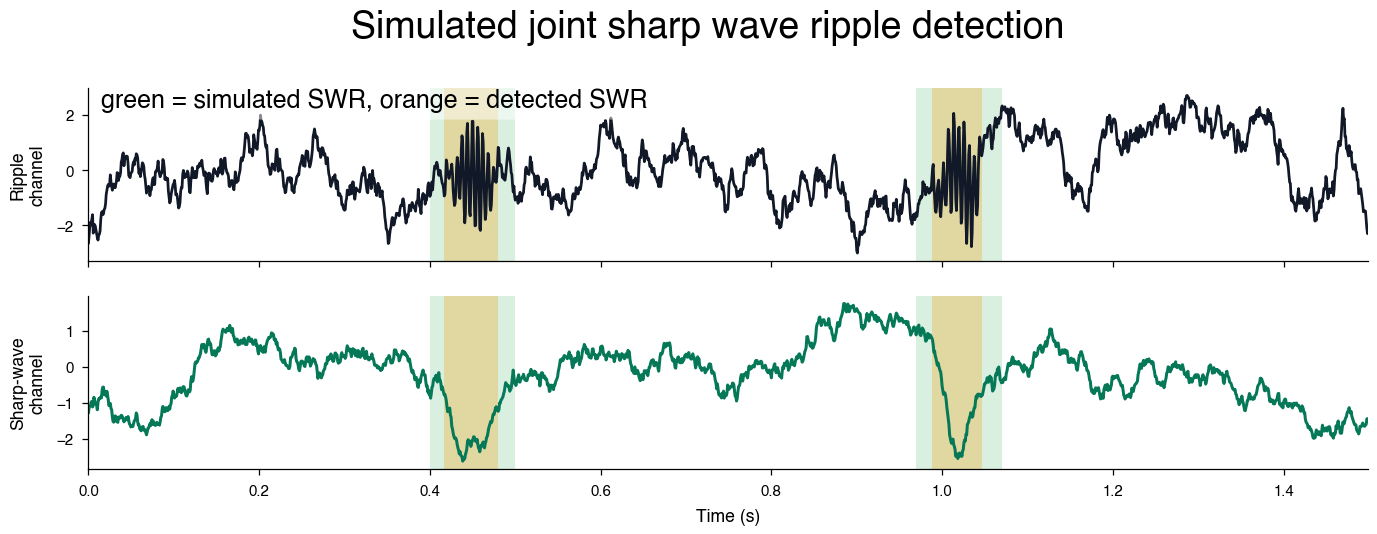

In [4]:
def plot_simulated_swr_result(events, truth, timestamps, ripple_raw, sharp_wave_raw):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=npy.plotting.set_size("nature_double", fraction=1.3, ratio=0.3),
        sharex=True,
        dpi=180,
    )
    ripple_ax, sharp_wave_ax = axes

    for row in truth.itertuples(index=False):
        for ax in axes:
            ax.axvspan(
                row.true_start,
                row.true_stop,
                color="#16a34a",
                alpha=0.16,
                lw=0,
                zorder=-1000,
            )
    for start, stop in events[["start", "stop"]].to_numpy():
        for ax in axes:
            ax.axvspan(start, stop, color="#f59e0b", alpha=0.30, lw=0, zorder=-900)

    ripple_ax.plot(timestamps, ripple_raw, color="#111827", lw=1.1)
    ripple_ax.set_ylabel("Ripple\nchannel")

    sharp_wave_ax.plot(timestamps, sharp_wave_raw, color="#047857", lw=1.2)
    sharp_wave_ax.set_ylabel("Sharp-wave\nchannel")
    sharp_wave_ax.set_xlabel("Time (s)")

    for ax in axes:
        ax.margins(x=0)
        ax.spines[["top", "right"]].set_visible(False)

    ripple_ax.text(
        0.01,
        1,
        "green = simulated SWR, orange = detected SWR",
        transform=ripple_ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "alpha": 0.5,
            "edgecolor": "none",
        },
    )
    return fig


fig = plot_simulated_swr_result(
    sim_events,
    sim_truth,
    sim_timestamps,
    sim_ripple,
    sim_sharp_wave,
)
fig.suptitle("Simulated joint sharp wave ripple detection", y=1.04, fontsize=15);


### Interactive browser demo

The embedded Marimo app below runs entirely in your browser with WebAssembly. It intentionally uses simulated data and a small NumPy/SciPy detector rather than importing the full `neuro_py` package, which keeps the demo fast and avoids browser dependency limits. Try changing the amplitudes, noise level, and thresholds to see how the joint detector responds.

<iframe
  src="marimo/sharp_wave_ripple_detection/index.html"
  width="100%"
  height="700"
  frameborder="0"
  sandbox="allow-scripts allow-same-origin allow-downloads allow-popups"
  loading="lazy"
  style="border: 1px solid var(--md-default-fg-color--lightest); border-radius: 0.5rem; width: 100%;"
></iframe>


## 2) Detect joint SWRs from a real session

With the simulated example in mind, we can run the same detector on real data. The detector can infer channels from CellExplorer `channelTags`:

- `ripple`, `Ripple`, `CA1sp`, or `ca1sp` for the ripple channel,
- `SharpWave`, `sharpwave`, `sharp_wave`, `CA1sr`, or `ca1sr` for the sharp-wave channel, and
- `Bad` or `bad` for an optional noise channel.

The important behavior is still joint detection by default: a candidate event must pass separate ripple and sharp-wave criteria. If a session does not have a usable sharp-wave channel, you can explicitly run ripple-only detection with `require_sharp_wave=False`, but those events should be interpreted more cautiously because the sharp-wave criterion helps reject ripple-band noise.


In [5]:
basepath = r"S:\data\HMC\HMC1\day8" # 12691.7

ripples = detect_sharp_wave_ripples(
    basepath=basepath,
    low_threshold=1.0,
    high_threshold=2.5,
    sharp_wave_low_threshold=0.25,
    sharp_wave_high_threshold=1.5,
    min_duration=0.020,
    max_duration=0.250,
    sharp_wave_min_duration=0.005,
    sharp_wave_max_duration=0.500,
    merge_gap=0.001,
    noise_threshold=10,
    min_inter_event_interval=0.025,
    peak_window=0.150,
    boundary_mode="union",
    save_mat=False, # CHANGE TO TRUE TO SAVE MATLAB FILE
)

In [6]:
ripples

,start,stop,peaks,center,duration,amplitude,frequency,peakNormedPower,ripple_channel,noise_peakNormedPower,ripple_duration,sharp_wave_peakNormedPower,sharp_wave_amplitude,sharp_wave_duration
0,1.0512,1.1264,1.1032,1.0888,0.0752,760.759106,152.210805,4.782693,261,2.197593,0.0752,2.422366,2940.482427,0.0264
1,7.0960,7.1648,7.1368,7.1304,0.0688,1086.031154,168.152198,8.196290,261,1.212196,0.0632,5.626167,6829.537229,0.0592
2,7.1768,7.2384,7.2144,7.2076,0.0616,1304.984970,150.874740,9.573347,261,2.108075,0.0616,7.564478,9182.428640,0.0408
3,7.4264,7.5176,7.4720,7.4720,0.0912,1218.558875,140.678647,8.721061,261,0.664760,0.0760,4.828709,5861.512967,0.0424
4,14.1352,14.2008,14.1640,14.1680,0.0656,571.949331,153.709476,3.518855,261,0.596309,0.0424,7.625344,9256.313835,0.0600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11371,23718.8024,23718.8568,23718.8320,23718.8296,0.0544,900.653660,116.882316,5.862642,261,-0.421557,0.0424,2.175996,2641.416257,0.0304
11372,23718.8576,23718.9184,23718.8912,23718.8880,0.0608,1003.267970,123.708513,6.719147,261,-0.079005,0.0512,2.662700,3232.220196,0.0480
11373,23720.4048,23720.4512,23720.4160,23720.4280,0.0464,755.675320,118.455691,4.712376,261,0.080638,0.0288,1.713672,2080.207093,0.0352
11374,23803.4384,23803.5000,23803.4528,23803.4692,0.0616,825.348764,149.988464,5.396754,261,0.279748,0.0416,6.506896,7898.643345,0.0592


### Parameter guide

The defaults are intentionally conservative, but these are the parameters you will most often tune while looking at example events:

- `low_threshold`: lower z-scored ripple-envelope threshold used to set ripple candidate boundaries.
- `high_threshold`: peak z-scored ripple-envelope threshold required to accept the ripple component.
- `sharp_wave_low_threshold`: lower z-scored sharp-wave threshold used to set sharp-wave candidate boundaries.
- `sharp_wave_high_threshold`: peak z-scored sharp-wave threshold required near the ripple peak.
- `min_duration` and `max_duration`: allowed ripple-component duration in seconds. Keep `max_duration` permissive enough for real long ripples.
- `sharp_wave_min_duration` and `sharp_wave_max_duration`: allowed sharp-wave-component duration in seconds.
- `noise_threshold`: optional rejection threshold on the noise-channel ripple-band feature.
- `merge_gap`: merge nearby candidate intervals separated by less than this gap in seconds. Smaller values help keep nearby ripple bursts separate.
- `peak_window`: maximum time window for associating a ripple candidate with its nearby sharp-wave partner.
- `boundary_mode`: use `"sharp_wave"` for sharp-wave event boundaries or `"union"` for the combined ripple/sharp-wave interval. `"union"` is useful when ripple bursts ride on the shoulder of a broader sharp wave.
- `require_sharp_wave`: keep the default `True` for joint SWR detection, or set `False` only when you intentionally want ripple-only detection because no sharp-wave channel is available.

### Best practices for parameter selection

A good detector should be tuned from examples, not just from the final event count. Start with the defaults, inspect a short window with raw ripple and sharp-wave channels, and verify that accepted events have a visible ripple burst paired with a downward sharp-wave deflection.

- Tune `high_threshold` first. Increasing it removes weak ripple-band events; decreasing it increases sensitivity but can admit noise.
- Tune `low_threshold` after `high_threshold`. This mostly changes candidate boundaries. Raising it can split nearby ripple bursts when the envelope valley stays above a very permissive threshold.
- Tune `sharp_wave_high_threshold` next. This is often the most useful way to reject ripple-band artifacts that do not have a convincing sharp wave.
- Keep `sharp_wave_polarity="negative"` for the usual case where sharp waves deflect downward. If example events show the sharp-wave feature is inverted, either swap/revisit channel choice or use `sharp_wave_polarity="positive"`.
- Use a small `merge_gap` such as 1 ms when tuning dense ripple bouts. Larger gaps can glue two nearby ripple bursts into one candidate before joint detection happens.
- Keep `max_duration` permissive if your data contain true long ripples. Do not rely on a short `max_duration` to split nearby events; use `low_threshold` and `merge_gap` instead.
- Increase `peak_window` when ripple bursts and sharp-wave troughs are visibly offset in time. A value around 100-150 ms can work well for broad sharp waves, especially with `boundary_mode="union"`.
- Use `boundary_mode="union"` when ripple bursts occur on the shoulder of the sharp wave and would be clipped by sharp-wave-only boundaries. Use `"sharp_wave"` when you want stricter sharp-wave-centered intervals.
- Use `threshold_mode="local"` when ripple or sharp-wave amplitudes change strongly across the session. Local thresholds are helpful for nonstationary recordings, but always inspect examples because they can change event counts relative to global z-scoring.
- Keep `min_inter_event_interval` near 25 ms when you want to avoid duplicate detections while still allowing nearby real SWRs. Increase it for stricter duplicate suppression.
- Prefer joint detection with `require_sharp_wave=True`. Use ripple-only mode only when no valid sharp-wave channel exists, and interpret those events more cautiously.
- Use a noise or bad channel when available. A conservative `noise_threshold` can remove muscle or hardware artifacts with ripple-band power.
- Leave `reject_edge_events=True` and `reject_artifacts=True` for normal use. These checks remove events near filter edges and windows with NaNs, flat traces, or clipped plateaus.
- After tuning, confirm detector invariants: events should be sorted, durations should be positive, peaks should fall inside `[start, stop]`, and example events should not cluster around obvious artifacts.

A practical workflow is to tune on several representative windows from different parts of the session, then run the full session with `save_mat=True`. If you change parameters later, use `overwrite=True` so the saved CellExplorer event file reflects the new detector settings.

See `detect_sharp_wave_ripples` for the full docstring and less commonly changed options such as passbands and smoothing widths.


## 3) Inspect the real-data detection output

The returned table follows the CellExplorer event convention and includes a few extra columns that are useful for QC:

- `peakNormedPower` reports the ripple feature strength,
- `sharp_wave_peakNormedPower` reports the sharp-wave feature strength, and
- `sharp_wave_duration` reports the duration of the sharp-wave component used for the final event boundary.


In [7]:
summary_columns = [
    "start",
    "stop",
    "peaks",
    "duration",
    "ripple_duration",
    "sharp_wave_duration",
    "frequency",
    "peakNormedPower",
    "sharp_wave_peakNormedPower",
    "noise_peakNormedPower",
]

print(f"Detected {len(ripples):,} joint SWR events")
display(ripples[summary_columns].head(10))


Detected 11,376 joint SWR events


,start,stop,peaks,duration,ripple_duration,sharp_wave_duration,frequency,peakNormedPower,sharp_wave_peakNormedPower,noise_peakNormedPower
0,1.0512,1.1264,1.1032,0.0752,0.0752,0.0264,152.210805,4.782693,2.422366,2.197593
1,7.0960,7.1648,7.1368,0.0688,0.0632,0.0592,168.152198,8.196290,5.626167,1.212196
2,7.1768,7.2384,7.2144,0.0616,0.0616,0.0408,150.874740,9.573347,7.564478,2.108075
3,7.4264,7.5176,7.4720,0.0912,0.0760,0.0424,140.678647,8.721061,4.828709,0.664760
4,14.1352,14.2008,14.1640,0.0656,0.0424,0.0600,153.709476,3.518855,7.625344,0.596309
5,14.6272,14.6832,14.6472,0.0560,0.0560,0.0360,163.644184,12.713671,6.487357,3.301809
6,22.3400,22.4008,22.3840,0.0608,0.0312,0.0608,172.125805,5.733974,7.285906,0.764961
7,26.8832,26.9432,26.9200,0.0600,0.0336,0.0456,130.276986,3.218880,8.845681,1.957444
8,34.4480,34.5256,34.4552,0.0776,0.0304,0.0432,131.247959,2.590872,5.050478,1.783983
9,34.7008,34.7592,34.7392,0.0584,0.0512,0.0344,153.718537,11.774589,6.308865,1.835325


## 4) Load only the real-data LFP segment needed for plotting

The full session can be large, so the tutorial does not materialize all plotted channels. Instead, we choose a short window from the first 20 minutes and pass that interval to `LFPLoader`. Internally this lets the loader use the file memmap and read just the requested time segment.

We then rebuild two lightweight feature traces inside that window: ripple-band power from the ripple channel and a low-frequency sharp-wave difference between the ripple and sharp-wave channels.


In [8]:
n_max_time = 20 * 60
print(
    f"Number of detected events in first {n_max_time} seconds: {(ripples.stop < n_max_time).sum()}"
)
channel_tags = npy.io.load_channel_tags(basepath)


def first_tagged_channel(tags, *keys):
    for key in keys:
        if key in tags:
            return int(np.atleast_1d(tags[key]["channels"])[0] - 1)
    return None


def zscore(values):
    values = np.asarray(values, dtype=float)
    scale = np.nanstd(values)
    if scale == 0 or np.isnan(scale):
        return np.zeros_like(values, dtype=float)
    return (values - np.nanmean(values)) / scale


ripple_channel = (
    int(ripples["ripple_channel"].iloc[0])
    if (
        not ripples.empty
        and "ripple_channel" in ripples.columns
        and not np.isnan(ripples["ripple_channel"].iloc[0])
    )
    else first_tagged_channel(channel_tags, "ripple", "Ripple", "CA1sp", "ca1sp")
)
sharp_wave_channel = first_tagged_channel(
    channel_tags, "SharpWave", "sharpwave", "sharp_wave", "CA1sr", "ca1sr"
)

if ripple_channel is None or sharp_wave_channel is None:
    raise ValueError(
        "This tutorial plot needs both ripple and sharp-wave channel tags."
    )

events_for_plot = (
    ripples.iloc[ripples.stop.values < n_max_time, :]
    .sort_values(["peakNormedPower", "sharp_wave_peakNormedPower"], ascending=False)
    .head(6)
)
plot_margin = 0.25
plot_start = max(0.0, float(events_for_plot["start"].min() - plot_margin))
plot_stop = float(events_for_plot["stop"].max() + plot_margin)
plot_epoch = np.array([[plot_start, plot_stop]])

lfp = npy.io.LFPLoader(
    basepath,
    channels=[ripple_channel, sharp_wave_channel],
    ext="lfp",
    epoch=plot_epoch,
)
fs = float(lfp.fs)
timestamps = np.asarray(lfp.abscissa_vals)
lfp_data = np.asarray(lfp.data)
raw = np.asarray(lfp_data[0]).squeeze()
sharp_wave_raw = np.asarray(lfp_data[1]).squeeze()

ripple_sos = signal.butter(4, (120.0, 250.0), btype="bandpass", fs=fs, output="sos")
ripple_filtered = signal.sosfiltfilt(ripple_sos, raw)
ripple_envelope = np.abs(signal.hilbert(ripple_filtered))
ripple_envelope = ndimage.gaussian_filter1d(
    ripple_envelope, sigma=0.004 * fs, mode="nearest"
)
ripple_power = zscore(ripple_envelope)

sharp_sos = signal.butter(4, (2.0, 50.0), btype="bandpass", fs=fs, output="sos")
ripple_low = signal.sosfiltfilt(sharp_sos, raw)
sharp_low = signal.sosfiltfilt(sharp_sos, sharp_wave_raw)
sharp_wave_diff = ripple_low - sharp_low
sharp_wave_power = zscore(sharp_wave_diff)

print(f"Ripple channel: {ripple_channel}")
print(f"Sharp-wave channel: {sharp_wave_channel}")
print(f"Loaded plotting window: {plot_start:.2f} to {plot_stop:.2f} s")
print(f"Loaded LFP shape: {lfp_data.shape}")
print(f"Sampling rate: {fs:.1f} Hz")


Number of detected events in first 1200 seconds: 459
Ripple channel: 261
Sharp-wave channel: 282
Loaded plotting window: 227.08 to 1029.31 s
Loaded LFP shape: (2, 1002791)
Sampling rate: 1250.0 Hz


## 5) Plot raw channels and feature traces

The overview stays intentionally simple: raw ripple channel and raw sharp-wave channel only, with accepted intervals shaded.

For individual examples, each event gets two stacked axes. The top axis shows the raw channels; the bottom axis shows the ripple and sharp-wave z-scored features with their high thresholds. This is easier to read than putting every trace on one set of axes, and it still shows the joint decision clearly.


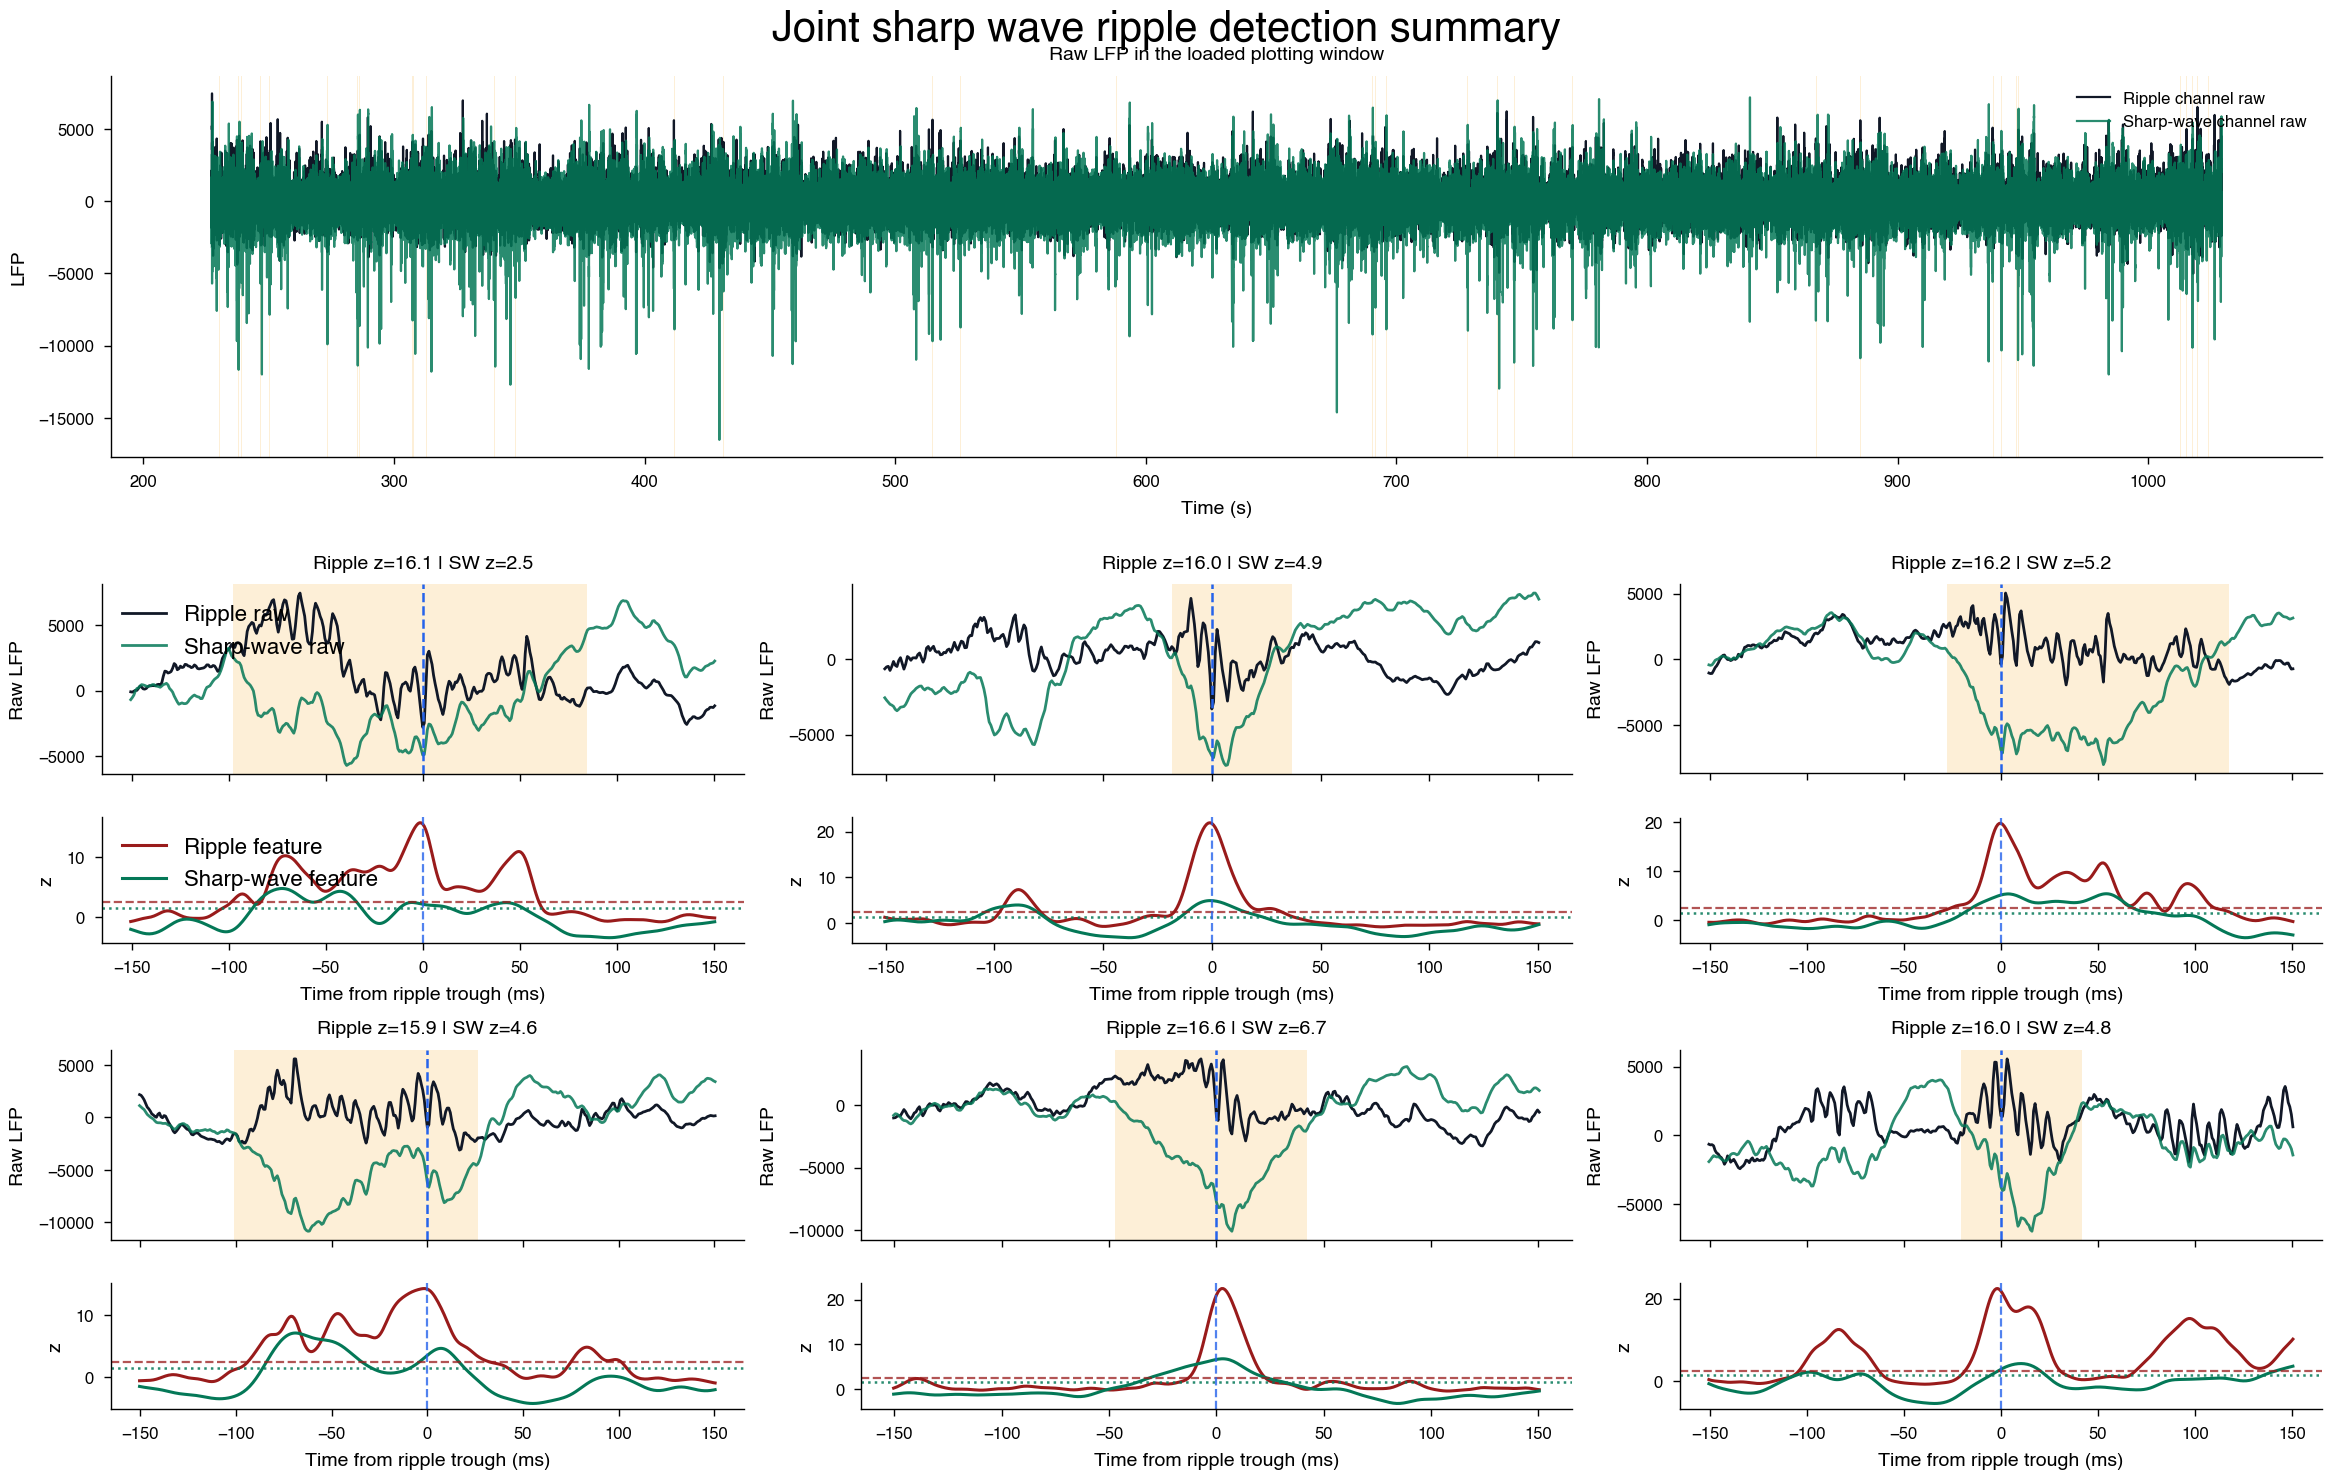

In [9]:
def plot_joint_swr_summary(
    events,
    events_for_plot,
    timestamps,
    ripple_raw,
    sharp_wave_raw,
    ripple_power,
    sharp_wave_power,
    fs,
    ripple_high_threshold=2.5,
    sharp_wave_high_threshold=1.5,
    example_window=0.150,
):
    fig = plt.figure(
        figsize=npy.plotting.set_size("nature_double", fraction=1.65),
        constrained_layout=True,
        dpi=200,
    )
    outer = fig.add_gridspec(2, 1, height_ratios=[0.9, 2.2], hspace=0.08)

    ax_overview = fig.add_subplot(outer[0, 0])
    ax_overview.plot(
        timestamps, ripple_raw, color="#111827", lw=0.8, label="Ripple channel raw"
    )
    ax_overview.plot(
        timestamps,
        sharp_wave_raw,
        color="#047857",
        lw=0.8,
        alpha=0.85,
        label="Sharp-wave channel raw",
    )
    for start, stop in events.loc[
        (events["stop"] >= timestamps[0]) & (events["start"] <= timestamps[-1]),
        ["start", "stop"],
    ].to_numpy():
        ax_overview.axvspan(start, stop, color="#f59e0b", alpha=0.16, lw=0)
    ax_overview.set_title("Raw LFP in the loaded plotting window")
    ax_overview.set_xlabel("Time (s)")
    ax_overview.set_ylabel("LFP")
    ax_overview.legend(loc="upper right", frameon=False)

    event_grid = outer[1, 0].subgridspec(2, 3, hspace=0.34, wspace=0.22)
    event_axes = event_grid.subplots().ravel()
    half_window = int(round(example_window * fs))

    for panel_index, (container_ax, (_, event)) in enumerate(
        zip(event_axes, events_for_plot.sort_values("peaks").iterrows())
    ):
        container_ax.axis("off")
        subgrid = container_ax.get_subplotspec().subgridspec(
            2, 1, height_ratios=[1.2, 0.8], hspace=0.05
        )
        raw_ax = fig.add_subplot(subgrid[0, 0])
        feature_ax = fig.add_subplot(subgrid[1, 0], sharex=raw_ax)

        peak_idx = int(np.argmin(np.abs(timestamps - event["peaks"])))
        start_idx = max(0, peak_idx - half_window)
        stop_idx = min(len(timestamps), peak_idx + half_window + 1)
        local_time = (timestamps[start_idx:stop_idx] - event["peaks"]) * 1000.0

        raw_ax.plot(
            local_time,
            ripple_raw[start_idx:stop_idx],
            color="#111827",
            lw=1.0,
            label="Ripple raw",
        )
        raw_ax.plot(
            local_time,
            sharp_wave_raw[start_idx:stop_idx],
            color="#047857",
            lw=1.0,
            alpha=0.85,
            label="Sharp-wave raw",
        )
        raw_ax.axvspan(
            (event["start"] - event["peaks"]) * 1000.0,
            (event["stop"] - event["peaks"]) * 1000.0,
            color="#f59e0b",
            alpha=0.16,
            lw=0,
        )
        raw_ax.axvline(0.0, color="#2563eb", ls="--", lw=0.9)
        raw_ax.set_title(
            f"Ripple z={event['peakNormedPower']:.1f} | SW z={event['sharp_wave_peakNormedPower']:.1f}"
        )
        raw_ax.set_ylabel("Raw LFP")
        raw_ax.tick_params(labelbottom=False)

        feature_ax.plot(
            local_time,
            ripple_power[start_idx:stop_idx],
            color="#991b1b",
            lw=1.1,
            label="Ripple feature",
        )
        feature_ax.plot(
            local_time,
            sharp_wave_power[start_idx:stop_idx],
            color="#047857",
            lw=1.1,
            label="Sharp-wave feature",
        )
        feature_ax.axhline(
            ripple_high_threshold, color="#991b1b", ls="--", lw=0.8, alpha=0.75
        )
        feature_ax.axhline(
            sharp_wave_high_threshold, color="#047857", ls=":", lw=0.9, alpha=0.85
        )
        feature_ax.axvline(0.0, color="#2563eb", ls="--", lw=0.8, alpha=0.8)
        feature_ax.set_xlabel("Time from ripple trough (ms)")
        feature_ax.set_ylabel("z")

        if panel_index == 0:
            raw_ax.legend(loc="upper left", frameon=False, fontsize=8)
            feature_ax.legend(loc="upper left", frameon=False, fontsize=8)

    for ax in event_axes[len(events_for_plot) :]:
        ax.axis("off")

    return fig


fig = plot_joint_swr_summary(
    ripples,
    events_for_plot,
    timestamps,
    raw,
    sharp_wave_raw,
    ripple_power,
    sharp_wave_power,
    fs,
    ripple_high_threshold=2.5,
    sharp_wave_high_threshold=1.5,
)
fig.suptitle("Joint sharp wave ripple detection summary", y=1.02, fontsize=15);


## 6) Save the final joint detections to a CellExplorer event file

After the thresholds look good, rerun the detector with `save_mat=True`. Using the default `event_name="ripples"` writes a standard CellExplorer event file named `basename.ripples.events.mat`.

```python
detect_sharp_wave_ripples(
    basepath=basepath,
    low_threshold=1.0,
    high_threshold=2.5,
    sharp_wave_low_threshold=0.25,
    sharp_wave_high_threshold=1.5,
    min_duration=0.020,
    max_duration=0.250,
    sharp_wave_min_duration=0.005,
    sharp_wave_max_duration=0.500,
    noise_threshold=10,
    merge_gap=0.001,
    min_inter_event_interval=0.025,
    peak_window=0.150,
    boundary_mode="union",
    save_mat=True,
    overwrite=True,
)
```

That file can then be loaded by CellExplorer or by `neuro_py.io.loading.load_ripples_events`.
